# Chapter 2 — The Physics of Radio Emission

In [Chapter 1](01_what_is_radio_astronomy.ipynb) we met the radio sky as Karl Jansky
heard it: a hiss of static that turned with the stars. We measured *brightness* in
janskys and got comfortable with the strange units radio astronomers use. But we
left a question hanging: **what is actually emitting those radio waves, and why does
the sky look so different at radio wavelengths than it does to the eye?**

This chapter answers that. The radio sky is dominated by two physical processes,
and a single number — the **spectral index** — lets us tell them apart from data
alone. Along the way we will see *why* radio astronomers measure temperatures
instead of brightnesses, an accident of physics that has shaped the whole field's
vocabulary.

## Learning goals

By the end of this chapter you will be able to:

- **Derive the Rayleigh–Jeans limit** of the Planck law and explain why it holds
  almost everywhere in the radio band — and therefore why we speak of *brightness
  temperature*.
- **Distinguish thermal emission** (free–free / bremsstrahlung) from **non-thermal
  emission** (synchrotron) by their spectra.
- **Define and measure the spectral index** $\alpha$, where $S_\nu \propto \nu^{\alpha}$,
  by fitting a real (here, synthetic-but-realistic) spectrum.

Everything runs on the base `jansky` environment with no network access.

## The physics, and the people who wrote it down

Two strands of early-twentieth-century physics meet in this chapter.

**The Rayleigh–Jeans law (1900–1905).** In trying to explain the spectrum of a
blackbody, Lord Rayleigh and Sir James Jeans derived — from classical
electromagnetism and equipartition — that the brightness of a thermal source
should grow as $\nu^2$. At optical frequencies this is famously *wrong*: it
predicts the "ultraviolet catastrophe", infinite energy at short wavelengths, and
was one of the puzzles that forced Planck to quantise radiation in 1900. But at the
**low** frequencies of the radio band, the Rayleigh–Jeans law is an excellent
approximation to Planck's full law — accurate to better than a part in $10^4$ across
most of radio astronomy. This is the single most useful piece of "wrong" physics in
the field.

**Synchrotron radiation (1940s–1950s).** When the first radio surveys revealed a
diffuse glow far brighter and far *steeper* in frequency than any hot gas could
produce, the explanation turned out to be relativistic electrons spiralling in
magnetic fields. The theory of this **synchrotron** (originally *magneto-bremsstrahlung*)
emission was worked out by Alfvén & Herlofson (1950), Kiepenheuer (1950), and
especially **Ginzburg & Syrovatskii (1965)**, and it remains the explanation for the
non-thermal radio sky — from supernova remnants to radio galaxies.

We follow the modern, accessible treatment in:

> **Condon, J. J. & Ransom, S. M.** *Essential Radio Astronomy* (Princeton University
> Press, 2016). Free online at
> [Essential Radio Astronomy (Condon & Ransom)](https://science.nrao.edu/opportunities/courses/era).
> Chapters 2 (radiation fundamentals), 4 (free–free), and 5 (synchrotron).

For the historical roots, see Rayleigh (Phil. Mag. 49, 539, 1900) and Jeans
(Phil. Mag. 10, 91, 1905) for the $\nu^2$ law, and Ginzburg, V. L. & Syrovatskii, S. I.
(1965, *Ann. Rev. Astron. Astrophys.* **3**, 297,
[ADS](https://ui.adsabs.harvard.edu/abs/1965ARA%26A...3..297G)) for synchrotron theory.

## 1 · From Planck to Rayleigh–Jeans

A blackbody at temperature $T$ radiates a specific intensity (brightness) given by
the **Planck law**:

$$
B_\nu(T) \;=\; \frac{2 h \nu^3}{c^2}\,\frac{1}{\,e^{h\nu / k_B T} - 1\,}
\qquad \left[\mathrm{W\,m^{-2}\,Hz^{-1}\,sr^{-1}}\right].
$$

The whole of radio astronomy lives in the corner where the photon energy is tiny
compared to the thermal energy:

$$
h\nu \;\ll\; k_B T .
$$

How small is $h\nu / k_B T$ in practice? At $\nu = 1.4\,\mathrm{GHz}$ (the
hydrogen-line frequency) and $T = 100\,\mathrm{K}$,

$$
\frac{h\nu}{k_B T} \approx \frac{(6.6\times10^{-34})(1.4\times10^{9})}{(1.4\times10^{-23})(100)}
\approx 7\times10^{-4} \ll 1 .
$$

When $x \equiv h\nu/k_B T \ll 1$ we can expand the exponential,
$e^{x} - 1 \approx x + \tfrac12 x^2 + \dots \approx x$, and the Planck law collapses to
the **Rayleigh–Jeans law**:

$$
\boxed{\,B_\nu^{\mathrm{RJ}}(T) \;=\; \frac{2 h \nu^3}{c^2}\,\frac{1}{h\nu/k_B T}
\;=\; \frac{2 k_B T \nu^2}{c^2}\,. }
$$

Two things are remarkable about this:

1. **Planck's constant has vanished.** The Rayleigh–Jeans brightness is purely
   classical — exactly the result Rayleigh and Jeans derived before quantum
   mechanics existed.
2. **Brightness is linear in temperature.** This is what makes the next idea
   possible.

This is the function `jansky.units.rayleigh_jeans_brightness` computes for us.

## 2 · Brightness temperature

Because $B_\nu^{\mathrm{RJ}} \propto T$, radio astronomers turn the relation around
and use brightness as a *thermometer*. The **brightness temperature** $T_b$ of *any*
source — thermal or not — is *defined* as the temperature a blackbody would need, in
the Rayleigh–Jeans limit, to produce the observed brightness:

$$
T_b \;\equiv\; \frac{c^2}{2 k_B \nu^2}\, B_\nu .
$$

It is just a convenient relabelling of intensity. For a genuinely thermal source
$T_b$ equals the physical temperature; for a synchrotron source it can reach
$10^{12}\,\mathrm{K}$ and is *not* a physical temperature at all — it merely encodes
how bright the source is.

To turn a brightness temperature into a measured **flux density** $S_\nu$ (what a
telescope actually records, in janskys), we integrate the brightness over the
source's solid angle $\Omega$:

$$
S_\nu \;=\; \int B_\nu \, d\Omega \;\approx\; B_\nu\,\Omega
\;=\; \frac{2 k_B \nu^2}{c^2}\,T_b\,\Omega .
$$

These are exactly `jansky.units.brightness_temperature_to_flux` and its inverse
`flux_to_brightness_temperature`. We will round-trip a number through them below to
confirm the relation is self-consistent.

## 3 · Two ways to make radio waves

### Thermal: free–free (bremsstrahlung)

In an ionised gas (an HII region, say) free electrons are deflected as they pass
ions. An accelerating charge radiates, so each near-miss emits a photon — this is
**free–free** or **bremsstrahlung** ("braking radiation") emission. Its spectrum is
nearly *flat* where the gas is optically thin: the flux density obeys a power law

$$
S_\nu \propto \nu^{\alpha}, \qquad \alpha \approx -0.1 ,
$$

i.e. essentially independent of frequency. (At low frequencies the source becomes
optically thick and turns over to the Rayleigh–Jeans slope $\alpha = +2$, but we will
work in the optically-thin regime.)

### Non-thermal: synchrotron

Relativistic electrons spiralling in a magnetic field radiate **synchrotron**
emission. If the electrons have a power-law *energy* distribution,
$N(E)\,dE \propto E^{-p}\,dE$ — which shock acceleration naturally produces — the
emitted spectrum is also a power law,

$$
S_\nu \propto \nu^{\alpha}, \qquad \alpha = -\frac{p-1}{2} .
$$

A typical electron index $p \approx 2.4$ gives $\alpha \approx -0.7$, the canonical
synchrotron slope. The key observational fact:

> **Thermal emission is flat ($\alpha \approx -0.1$); synchrotron emission is steep
> and negative ($\alpha \approx -0.7$ to $-1$).** Measuring $\alpha$ tells you which
> process you are looking at.

### The spectral index

The **spectral index** $\alpha$ is the defining quantity:

$$
\boxed{\,\alpha \;\equiv\; \frac{d\,\log S_\nu}{d\,\log \nu}\,. }
$$

(Beware the sign convention: some authors define $S_\nu \propto \nu^{-\alpha}$ so that
synchrotron has *positive* $\alpha \approx +0.7$. We use $S_\nu \propto \nu^{+\alpha}$
throughout, matching `jansky.signals`.) On log–log axes a power law is a straight
line of slope $\alpha$, which is exactly why we fit spectra in log space — and what we
do in the final section.

## Code

Let's make all of this concrete. First the imports and the course plot style.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

import astropy.units as u
import astropy.constants as const

from scipy.optimize import curve_fit

from jansky import units, signals, plotting

plotting.use_jansky_style()

rng = signals.rng(seed=42)  # reproducible noise
print("astropy", u.__package__, "ready")

astropy astropy.units ready


### 1 · Where the Rayleigh–Jeans approximation holds

We compute the full Planck brightness $B_\nu(T)$ and the Rayleigh–Jeans
approximation $B_\nu^{\mathrm{RJ}}(T)$ over a huge frequency range — from $10\,$MHz
(low radio) up into the infrared — for a $T = 100\,\mathrm{K}$ source, and look at
where they agree. We use `astropy.constants` for $h$, $k_B$, $c$ so there are no
hand-typed numbers, and `jansky.units.rayleigh_jeans_brightness` for the RJ curve.

In [2]:
def planck_brightness(temperature, frequency):
    # Full Planck law B_nu(T), returned in W m^-2 Hz^-1 sr^-1.
    temperature = u.Quantity(temperature, u.K)
    frequency = u.Quantity(frequency, u.Hz)
    x = (const.h * frequency / (const.k_B * temperature)).to_value(u.dimensionless_unscaled)
    b_nu = (2 * const.h * frequency**3 / const.c**2) / np.expm1(x) / u.sr
    return b_nu.to(u.W / u.m**2 / u.Hz / u.sr)


T = 100 * u.K
freq = np.logspace(7, 13, 600) * u.Hz   # 10 MHz -> 10 THz

B_planck = planck_brightness(T, freq)
B_rj = units.rayleigh_jeans_brightness(T, freq)   # jansky helper

# Fractional error of the RJ approximation, and the photon-to-thermal ratio.
frac_err = np.abs(B_rj - B_planck) / B_planck
x_ratio = (const.h * freq / (const.k_B * T)).to_value(u.dimensionless_unscaled)

# Frequency at which RJ is off by 1%.
i_1pct = np.argmax(frac_err.value > 0.01)
nu_1pct = freq[i_1pct].to(u.GHz)
print(f"At T = {T:.0f}:")
print(f"  RJ is accurate to <1% below {nu_1pct:.1f} (h*nu/k_B*T = {x_ratio[i_1pct]:.3f})")
print(f"  At 1.4 GHz: fractional error = {np.interp(1.4e9, freq.value, frac_err.value):.2e}")

At T = 100 K:
  RJ is accurate to <1% below 42.3 GHz (h*nu/k_B*T = 0.020)
  At 1.4 GHz: fractional error = 3.36e-04


### Figure 1 — Planck vs Rayleigh–Jeans across the spectrum

Left: the two brightness curves. They are indistinguishable through the entire radio
band and only diverge as $h\nu \to k_B T$ near the Planck peak. Right: the fractional
error of the approximation, with the radio band shaded and the 1% line marked.

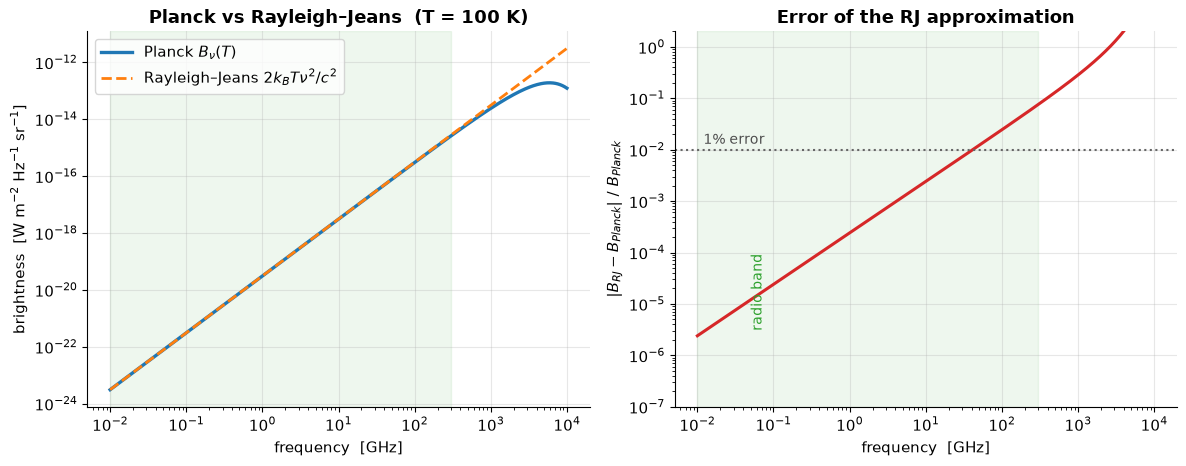

In [3]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.8))

# --- Left: the curves on log-log axes ---
ax1.loglog(freq.to(u.GHz), B_planck.value, lw=2.4, label="Planck $B_\\nu(T)$")
ax1.loglog(freq.to(u.GHz), B_rj.value, lw=2.0, ls="--",
           label="Rayleigh–Jeans $2k_BT\\nu^2/c^2$")
ax1.set_xlabel("frequency  [GHz]")
ax1.set_ylabel("brightness  [W m$^{-2}$ Hz$^{-1}$ sr$^{-1}$]")
ax1.set_title(f"Planck vs Rayleigh–Jeans  (T = {T.value:.0f} K)")
ax1.legend(loc="upper left")
# Mark the radio band (roughly 10 MHz - 300 GHz).
ax1.axvspan(0.01, 300, color="tab:green", alpha=0.08)

# --- Right: fractional error ---
ax2.loglog(freq.to(u.GHz), frac_err.value, color="tab:red", lw=2.2)
ax2.axhline(0.01, color="0.4", ls=":", lw=1.5)
ax2.text(0.012, 0.013, "1% error", color="0.3", fontsize=10)
ax2.axvspan(0.01, 300, color="tab:green", alpha=0.08)
ax2.text(0.05, 3e-6, "radio band", color="tab:green", fontsize=10, rotation=90,
         va="bottom")
ax2.set_xlabel("frequency  [GHz]")
ax2.set_ylabel("|$B_{RJ} - B_{Planck}$| / $B_{Planck}$")
ax2.set_title("Error of the RJ approximation")
ax2.set_ylim(1e-7, 2)

fig.tight_layout()
plt.show()

The takeaway: across the radio band the Rayleigh–Jeans law tracks Planck to a part in
ten-thousand or better. *That* is why radio astronomers can get away with treating
brightness as a temperature — the approximation is essentially exact for them, while
it is hopeless at optical wavelengths.

### 2 · Brightness temperature ↔ flux density (a round-trip)

Now we check the brightness-temperature machinery. Take a compact source — say a
patch of $T_b = 8000\,\mathrm{K}$ ionised gas, $1\,\mathrm{arcmin}^2$ on the sky,
observed at $1.4\,\mathrm{GHz}$ — convert it to a flux density in janskys, and convert
straight back. The two `jansky.units` helpers invert each other analytically, so we
should recover the input temperature exactly.

In [4]:
T_b = 8000 * u.K
nu = 1.4 * u.GHz
omega = (1.0 * u.arcmin**2).to(u.sr)   # 1 square arcminute as a solid angle

# Forward: brightness temperature -> flux density (janskys)
S = units.brightness_temperature_to_flux(T_b, nu, omega)

# Inverse: flux density -> brightness temperature
T_b_recovered = units.flux_to_brightness_temperature(S, nu, omega)

print(f"Source:    T_b = {T_b:.0f},  Omega = {omega:.3e},  nu = {nu}")
print(f"Forward:   S_nu = {S.to(u.mJy):.4f}  ({S.to(u.Jy):.6f})")
print(f"Inverse:   T_b  = {T_b_recovered:.3f}")
print(f"Round-trip error: {abs(T_b_recovered - T_b):.2e}")

assert u.isclose(T_b_recovered, T_b, rtol=1e-9), "round-trip should be exact"
print("\\nRound-trip exact ✓")

Source:    T_b = 8000 K,  Omega = 8.462e-08 sr,  nu = 1.4 GHz
Forward:   S_nu = 40763.3779 mJy  (40.763378 Jy)
Inverse:   T_b  = 8000.000 K
Round-trip error: 0.00e+00 K
\nRound-trip exact ✓


The conversion is linear in both $T_b$ and $\Omega$, so halving the solid angle (or the
brightness temperature) halves the flux. A patch this size and temperature comes out at
a few tens of janskys; shrink it to a single arcsecond$^2$ and the same temperature
becomes a *micro*jansky source — which is why mapping faint extended emission demands
both sensitivity and the angular resolution we build toward in Part III.

### 3 · Measuring the spectral index

Here is the payoff. We build a realistic two-component spectrum with
`jansky.signals.synthetic_spectrum`: a **flat thermal** floor plus a **steep
synchrotron** power law with a *known* spectral index, contaminated with measurement
noise. Then we pretend we don't know the answer and **recover $\alpha$** from the
data with `scipy.optimize.curve_fit`.

We do it two ways, to make an important point:

- **Naïve single power-law fit.** Fit only $S \propto \nu^\alpha$. A single power law
  *is* a straight line on log–log axes, so this is tempting — but the flat thermal
  floor adds flux at high frequency (where the synchrotron power law has dropped to a
  fraction of a jansky), pulling the inferred slope toward zero. The result is
  **biased flat**.
- **Full two-component fit.** Fit $S = S_\mathrm{th} + A\,(\nu/\nu_0)^\alpha$, modelling
  the thermal floor explicitly. This recovers the injected $\alpha$ within its
  uncertainty.

Both fits are done with `scipy.optimize.curve_fit`. The lesson — *model what is
actually in your data* — is one every spectral-index measurement has to confront.

In [5]:
# --- Build the synthetic spectrum (true answer is known) ---
nu0 = 1.0          # reference frequency, GHz
alpha_true = -0.8  # true synchrotron spectral index
thermal_amp = 0.5  # flat thermal floor (Jy)
synch_amp = 10.0   # synchrotron flux at nu0 (Jy)

freq_ghz = np.logspace(np.log10(0.1), np.log10(30.0), 24)  # 100 MHz - 30 GHz
flux = signals.synthetic_spectrum(
    freq_ghz,
    thermal_amp=thermal_amp,
    nonthermal_amp=synch_amp,
    spectral_index=alpha_true,
    reference=nu0,
    noise=0.05,
    seed=7,
)
# The measurement error is the true noise sigma used to generate the data above
# (constant additive Gaussian, 0.05 Jy). Using the generating sigma here makes the
# quoted parameter uncertainties from curve_fit statistically self-consistent.
flux_err = np.full_like(flux, 0.05)

# --- Model 1: a single power law, S = A * (nu/nu0)^alpha ---
def power_law_model(nu, amp, alpha):
    return amp * (nu / nu0) ** alpha

p_pow, c_pow = curve_fit(power_law_model, freq_ghz, flux, sigma=flux_err,
                         absolute_sigma=True, p0=[10.0, -0.7])
alpha_pow = p_pow[1]
alpha_pow_err = np.sqrt(c_pow[1, 1])

# --- Model 2: thermal floor + power law, S = S_th + A * (nu/nu0)^alpha ---
def two_component_model(nu, s_th, amp, alpha):
    return s_th + amp * (nu / nu0) ** alpha

p_two, c_two = curve_fit(two_component_model, freq_ghz, flux, sigma=flux_err,
                         absolute_sigma=True, p0=[0.3, 10.0, -0.7])
s_th_fit, amp_fit, alpha_two = p_two
alpha_two_err = np.sqrt(c_two[2, 2])

print(f"True spectral index:           alpha = {alpha_true:+.3f}\\n")
print("Model 1 — single power law (ignores thermal floor):")
print(f"    alpha = {alpha_pow:+.3f} ± {alpha_pow_err:.3f}"
      f"   ({abs(alpha_pow - alpha_true)/alpha_pow_err:.1f} sigma from truth — biased flat)")
print("\\nModel 2 — thermal floor + power law:")
print(f"    alpha   = {alpha_two:+.3f} ± {alpha_two_err:.3f}"
      f"   ({abs(alpha_two - alpha_true)/alpha_two_err:.1f} sigma from truth)")
print(f"    S_therm = {s_th_fit:.2f} Jy   (true {thermal_amp:.1f})")
print(f"    A_synch = {amp_fit:.2f} Jy   (true {synch_amp:.1f})")

True spectral index:           alpha = -0.800\n
Model 1 — single power law (ignores thermal floor):
    alpha = -0.780 ± 0.001   (28.9 sigma from truth — biased flat)
\nModel 2 — thermal floor + power law:
    alpha   = -0.799 ± 0.001   (0.9 sigma from truth)
    S_therm = 0.46 Jy   (true 0.5)
    A_synch = 10.03 Jy   (true 10.0)


### Figure 2 — A two-component spectrum and its recovered index

The data (points with error bars), both fits, and the two underlying components — the
flat thermal floor and the steep synchrotron power law — all on log–log axes. The
naïve single power law (orange) bends to chase the thermal floor at high frequency and
ends up too flat; the two-component fit (green) lies right on the true total and
recovers the injected slope.

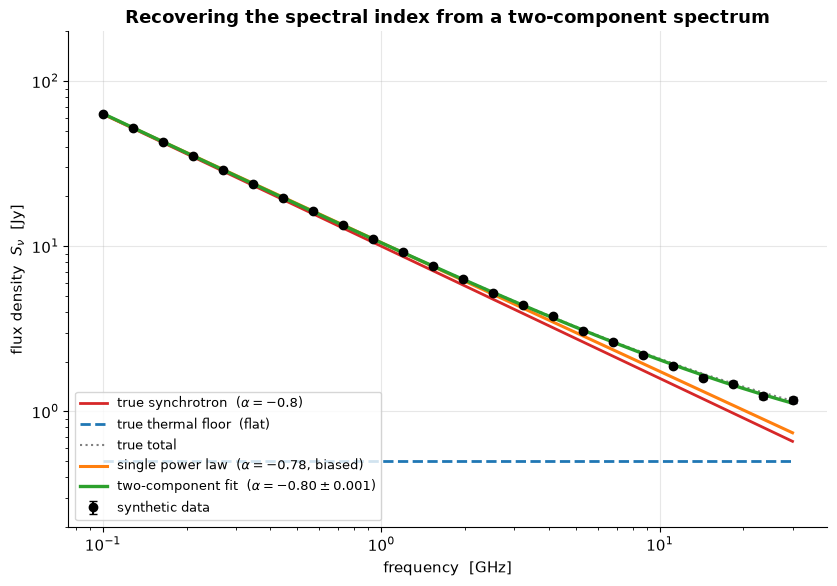

In [6]:
fig, ax = plt.subplots(figsize=(8.5, 6))

# Smooth model components for plotting.
nu_fine = np.logspace(np.log10(0.1), np.log10(30.0), 300)
thermal_component = np.full_like(nu_fine, thermal_amp)
synch_component = signals.power_law(nu_fine, synch_amp, alpha_true, reference=nu0)
total_component = thermal_component + synch_component
fit_pow = power_law_model(nu_fine, *p_pow)
fit_two = two_component_model(nu_fine, *p_two)

# Data with error bars.
ax.errorbar(freq_ghz, flux, yerr=flux_err, fmt="o", ms=6, color="k",
            capsize=3, zorder=6, label="synthetic data")

# True components.
ax.loglog(nu_fine, synch_component, lw=2, color="tab:red",
          label=f"true synchrotron  ($\\alpha = {alpha_true:+.1f}$)")
ax.loglog(nu_fine, thermal_component, lw=2, ls="--", color="tab:blue",
          label="true thermal floor  (flat)")
ax.loglog(nu_fine, total_component, lw=1.5, ls=":", color="0.5",
          label="true total")

# The two fits.
ax.loglog(nu_fine, fit_pow, lw=2.2, color="tab:orange",
          label=f"single power law  ($\\alpha = {alpha_pow:+.2f}$, biased)")
ax.loglog(nu_fine, fit_two, lw=2.4, color="tab:green",
          label=f"two-component fit  ($\\alpha = {alpha_two:+.2f} \\pm {alpha_two_err:.3f}$)")

ax.set_xlabel("frequency  [GHz]")
ax.set_ylabel("flux density  $S_\\nu$  [Jy]")
ax.set_title("Recovering the spectral index from a two-component spectrum")
ax.legend(loc="lower left", fontsize=9.5)
ax.set_ylim(0.2, 200)

fig.tight_layout()
plt.show()

The two-component fit recovers the injected index to within its uncertainty, while the
naïve single power law is biased flat by the thermal floor it ignores. In a real survey
this is precisely how a source is classified: measure $S_\nu$ at several frequencies,
fit for the slope, and read off whether you are looking at thermal gas
($\alpha \approx -0.1$) or a synchrotron source ($\alpha \approx -0.7$ or steeper) — being
careful, as here, to model every component that contributes flux.

## Try it yourself

1. **Two-point spectral index.** In practice you often have flux densities at just
   *two* frequencies. The spectral index between $\nu_1$ and $\nu_2$ is
   $$\alpha = \frac{\log(S_2/S_1)}{\log(\nu_2/\nu_1)}.$$
   Write a one-line function `two_point_index(nu1, S1, nu2, S2)` and apply it to two
   points of the synthetic spectrum above — first a low/high pair that straddles the
   thermal floor (e.g. 0.5 GHz and 5 GHz), then a high pair safely in the
   synchrotron-dominated regime (e.g. 10 GHz and 30 GHz). Compare both to the fitted
   $\alpha$. Why does the low-frequency pair give a *flatter* (less negative) index?

2. **A thermal source instead.** Re-run the synthetic-spectrum cell with
   `spectral_index=-0.1` and a small `nonthermal_amp` (say 1.0) so the source is
   thermal-dominated. Refit. Confirm you recover a flat index, and explain how an
   observer would classify this source.

3. **How cold can Rayleigh–Jeans go?** Repeat the Planck-vs-RJ comparison for the
   cosmic microwave background, $T = 2.725\,\mathrm{K}$. At what frequency does the RJ
   approximation break by 1% now? (Hint: the answer scales with $T$ — the CMB peaks in
   the *microwave*, so RJ fails at lower frequencies than for a 100 K source.) Use
   `units.rayleigh_jeans_brightness` and the `planck_brightness` helper defined above.

## Recap

- The **Planck law** describes thermal radiation; in the radio band, where
  $h\nu \ll k_B T$, it reduces to the classical **Rayleigh–Jeans law**
  $B_\nu = 2 k_B T \nu^2 / c^2$. We showed this approximation is good to $\sim10^{-4}$
  across the whole radio band — the reason radio astronomers use brightness
  temperature.
- **Brightness temperature** $T_b$ is brightness expressed as the equivalent RJ
  blackbody temperature. We round-tripped a source through
  `brightness_temperature_to_flux` and `flux_to_brightness_temperature` and recovered
  it exactly.
- The radio sky is built from **thermal free–free** emission (flat,
  $\alpha \approx -0.1$) and **non-thermal synchrotron** emission (steep,
  $\alpha \approx -0.7$). The **spectral index** $\alpha$, defined by
  $S_\nu \propto \nu^\alpha$, distinguishes them — and we recovered an injected $\alpha$
  from a noisy two-component spectrum with `scipy.optimize.curve_fit`.

## What's next

We now know *what* the sky emits and *how bright* it is. [Chapter 3 — Noise and the
Radiometer Equation](03_signals_noise_radiometer.ipynb) tackles the other
half of any measurement: the **noise** that the signal has to climb out of. We will
meet Dicke's radiometer equation, $\Delta T = T_\mathrm{sys}/\sqrt{B\tau}$, and watch a
faint signal emerge from static as we integrate down — the engine behind
`jansky.signals.integrate_noise`. The brightness temperatures of this chapter become
the *antenna* and *system* temperatures of the next.